# 🎨 AI Productivity Gains in different Situations
**Source:** [Does AI Actually Boost Developer Productivity? (Stanford 100k Devs Study)](https://www.youtube.com/watch?v=tbDDYKRFjhk)

This post (and Jupyter notebook behind the scenes) builds on data from the [Does AI Actually Boost Developer Productivity? (Stanford 100k Devs Study)](https://www.youtube.com/watch?v=tbDDYKRFjhk) to explore a question that matters to every engineering team right now: where does AI actually move the needle on developer productivity, and where does it fall short?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 1. GLOBAL STYLE SETTINGS
# Use 'poster' context for large, readable fonts. Use 'white' style for a clean look.
sns.set_theme(style="white", context="poster")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.titlesize'] = 24
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Helper to format ranges nicely
def fmt_range(r):
    return f"{'+' if r[0] >= 0 else ''}{r[0]}–{r[1]}%"

## 1. Project Maturity: The "Legacy Drag" Effect
One of the most practically useful frameworks from the talk is a simple matrix that maps out when AI assistance actually pays off for software developers. Rather than making broad claims about AI productivity, it breaks the question down across two dimensions: how mature the codebase is, and how complex the task at hand is. The results are more nuanced than the usual hype suggests.

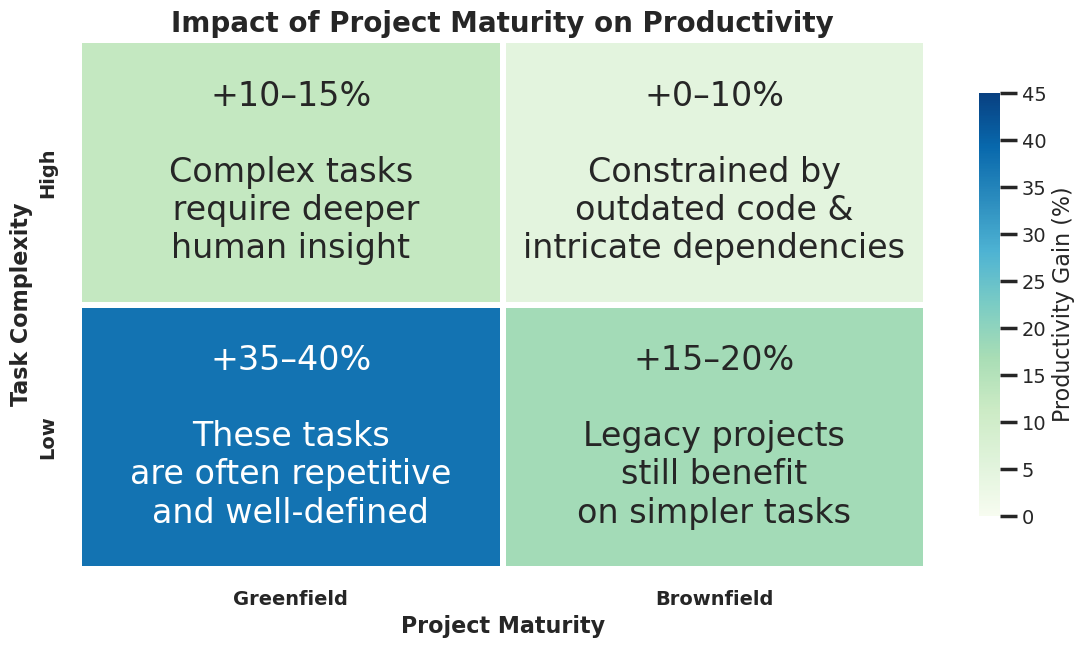

In [2]:
# Data Intervals
g_high, g_low = [10, 15], [35, 40]
b_high, b_low = [0, 10],  [15, 20]

# Matrix & Labels
maturity_data = np.array([[np.mean(g_high), np.mean(b_high)], 
                          [np.mean(g_low),  np.mean(b_low)]])

labels = np.array([
    [f"{fmt_range(g_high)}\n\nComplex tasks\n require deeper\nhuman insight",          f"{fmt_range(b_high)}\n\nConstrained by\noutdated code &\nintricate dependencies"],
    [f"{fmt_range(g_low)}\n\nThese tasks\nare often repetitive\nand well-defined",    f"{fmt_range(b_low)}\n\nLegacy projects\nstill benefit\non simpler tasks"]
])

plt.figure(figsize=(12, 7))
ax = sns.heatmap(maturity_data, annot=labels, fmt="", 
                 cmap="GnBu", vmin=0, vmax=45,
                 linewidths=4, linecolor='white',
                 cbar_kws={'label': 'Productivity Gain (%)', 'shrink': 0.8})

ax.set_xticklabels(['Greenfield', 'Brownfield'], weight='bold')
ax.set_yticklabels(['High', 'Low'], weight='bold', rotation=90)
ax.set_xlabel('Project Maturity', weight='bold')
ax.set_ylabel('Task Complexity', weight='bold')
plt.title("Impact of Project Maturity on Productivity", weight='bold')
plt.tight_layout()
plt.show()

## 2. Language Popularity: The "Niche Penalty"
The second chart from the talk above shifts the lens from project maturity to programming language choice, a dimension that is often overlooked in discussions about AI productivity. It turns out that the language you work in has a substantial impact on how much AI can actually help, driven primarily by how much training data exists for that language in the first place.

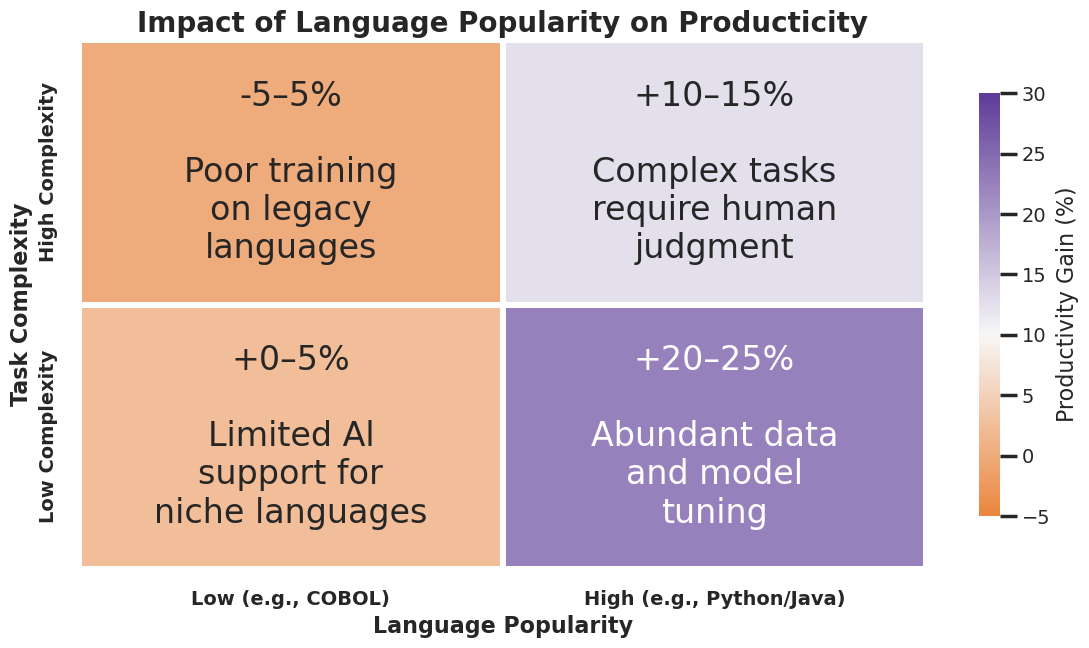

In [3]:
# Data Intervals
p_high, p_low = [10, 15], [20, 25]
n_high, n_low = [-5, 5], [0, 5]

lang_data = np.array([[np.mean(n_high), np.mean(p_high)], 
                      [np.mean(n_low),  np.mean(p_low)]])

labels = np.array([
    [f"{fmt_range(n_high)}\n\nPoor training\non legacy\nlanguages",    f"{fmt_range(p_high)}\n\nComplex tasks\nrequire human\njudgment"],
    [f"{fmt_range(n_low)}\n\nLimited Al\nsupport for\nniche languages", f"{fmt_range(p_low)}\n\nAbundant data\nand model\ntuning"]
])

plt.figure(figsize=(12, 7))
cmap = LinearSegmentedColormap.from_list("custom_div", ["#e66101", "#f7f7f7", "#5e3c99"])
ax = sns.heatmap(lang_data, annot=labels, fmt="", 
                 cmap=cmap, center=10, vmin=-5, vmax=30,
                 linewidths=4, linecolor='white',
                 cbar_kws={'label': 'Productivity Gain (%)', 'shrink': 0.8})

ax.set_xticklabels(['Low (e.g., COBOL)', 'High (e.g., Python/Java)'], weight='bold')
ax.set_yticklabels(['High', 'Low'], weight='bold', rotation=90)
ax.set_xlabel('Language Popularity', weight='bold')
ax.set_ylabel('Task Complexity', weight='bold')


ax.set_yticklabels(['High Complexity', 'Low Complexity'], weight='bold', rotation=90)
plt.title("Impact of Language Popularity on Producticity", weight='bold')
plt.tight_layout()
plt.show()

## 3. The Combined Story: "AI Heaven" or "AI Hell"
This final chart I made combines the means of the productivity gains from the previous two charts to create a third view, based on language popularity and project type. For each quadrant, the midpoints of both complexity levels are averaged together, giving equal weight to low and high complexity tasks.

*Note: This combined view is not a formally validated model but rather a pragmatic experiment, blending two independent data sources through simple averaging. It is meant to spark directional thinking rather than serve as a precise prediction.*

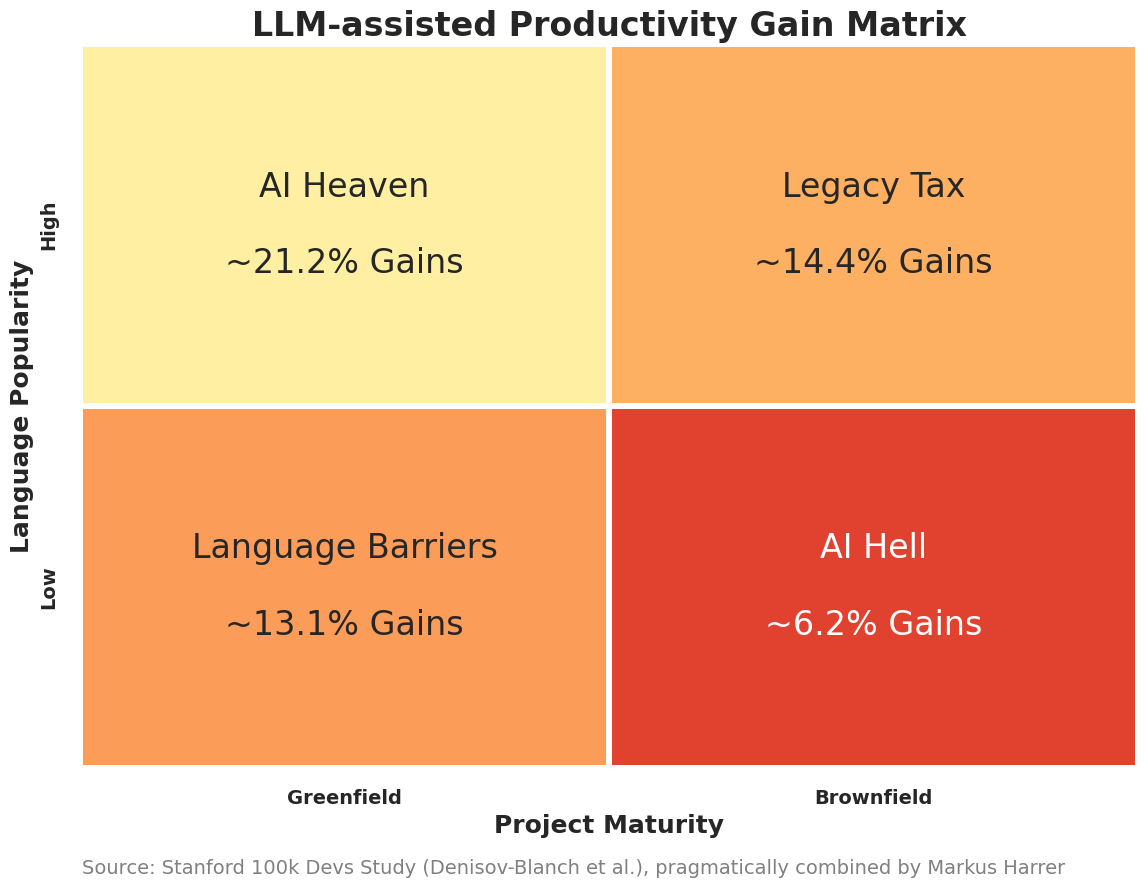

In [4]:
# Calculate Combined Midpoints
def calc_mean(m, l): return (np.mean(m) + np.mean(l)) / 2

heaven = (calc_mean(g_low, p_low) + calc_mean(g_high, p_high)) / 2
meh    = (calc_mean(b_low, p_low) + calc_mean(b_high, p_high)) / 2
cmon   = (calc_mean(g_low, n_low) + calc_mean(g_high, n_high)) / 2
danger    = (calc_mean(b_low, n_low) + calc_mean(b_high, n_high)) / 2

mean_data = np.array([[heaven, meh], [cmon, danger]])

# Detailed Storytelling Labels
mean_labels = np.array([
    [f"AI Heaven\n\n~{heaven:.1f}% Gains",  f"Legacy Tax\n\n~{meh:.1f}% Gains"],
    [f"Language Barriers\n\n~{cmon:.1f}% Gains", f"AI Hell\n\n~{danger:.1f}% Gains"]
])

plt.figure(figsize=(12, 9))

vmax_color_headroom = vmax=max([np.mean(g_low), np.mean(b_low), np.mean(p_low), np.mean(n_low),
          np.mean(g_high), np.mean(b_high), np.mean(p_high), np.mean(n_high)]) + 10

# RdYlGn is perfect here: Red (Danger) -> Green (Heaven)
ax = sns.heatmap(mean_data, annot=mean_labels, fmt="", 
                 cmap="RdYlGn", vmin=0, vmax=vmax_color_headroom,
                 linewidths=4, linecolor='white',
                 cbar=False) # No colorbar needed, labels tell the story

ax.set_xticklabels(['Greenfield', 'Brownfield'], weight='bold')
ax.set_yticklabels(['High', 'Low'], weight='bold', rotation=90)
ax.set_ylabel('Language Popularity', fontsize=18, weight='bold')
ax.set_xlabel('Project Maturity', fontsize=18, weight='bold')

plt.title("LLM-assisted Productivity Gain Matrix", fontsize=24, weight='heavy')
plt.figtext(0.5, 0, "Source: Stanford 100k Devs Study (Denisov-Blanch et al.), pragmatically combined by Markus Harrer", 
            ha="center", fontsize=14, color="gray")


plt.tight_layout()
plt.show()